In [1]:

import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import hvplot.pandas 
# hv.renderer('bokeh').theme = 'dark_minimal'


# Data Loading
It is always a good advice to use standard formats to transfer data from one computer to another. One of the most used formats is parquet. The following code should help you to load the data into your python environment.

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema
    



rds_u4 = RawDataset(dataset_root, "VG4", load_synthetic=False, load_training=True)
rds_u5 = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=True)
rds_u6 = RawDataset(dataset_root, "VG6", load_synthetic=True)




# Operation Modes

As you can see, the operation modes (at the very bottom) are not in the info schema, but you can find them when you explore the parquet schema (metadata of the parquet data file).

In [23]:
print(RawDataset.read_parquet_schema_df(dataset_root / "VG4_generator_data_testing_real_measurements.parquet").to_markdown())

|    | column                            | pa_dtype              |
|---:|:----------------------------------|:----------------------|
|  0 | tot_activepower                   | double                |
|  1 | plant_tmp                         | double                |
|  2 | ext_tmp                           | double                |
|  3 | water_primary_cold_tmp            | double                |
|  4 | water_primary_hot_tmp             | double                |
|  5 | valve_opening                     | double                |
|  6 | refri_bath_level                  | double                |
|  7 | aspi_bath_level                   | double                |
|  8 | canal_level                       | double                |
|  9 | canal_tmp                         | double                |
| 10 | water_primary_filter_out_pressure | double                |
| 11 | water_primary_filter_in_pressure  | double                |
| 12 | lake_tmp                          | double             

In [ ]:
print(RawDataset.read_parquet_schema_df(dataset_root / "VG5_generator_data_testing_real_measurements.parquet").to_markdown())

|    | column                         | pa_dtype              |
|---:|:-------------------------------|:----------------------|
|  0 | tot_activepower                | double                |
|  1 | ext_tmp                        | double                |
|  2 | plant_tmp                      | double                |
|  3 | charge                         | double                |
|  4 | coupler_position               | double                |
|  5 | injector_01_opening            | double                |
|  6 | injector_02_opening            | double                |
|  7 | injector_03_opening            | double                |
|  8 | injector_04_opening            | double                |
|  9 | injector_05_opening            | double                |
| 10 | pump_calculated_flow           | double                |
| 11 | pump_pressure_diff             | double                |
| 12 | pump_rotspeed                  | double                |
| 13 | tot_current                    | 

We can use `head()` to glance at the data.

In [4]:
rds_u4.data_dict["train"].info.head()

,Unnamed: 0,signal_name,attribute_name,asset,unit,element,signal_type,control_signal,input_feature,output_feature,core_attribute
0,0,FMHL_SUP_VEY.MHL_VG4_G4_P,tot_activepower,Veytaux 1,VG4,Generator,Measurement,False,True,True,False
1,1,FMHL_SUP_VEY.MHL_VGE_PRAP_TEMP_USINE,plant_tmp,Veytaux 1,General,Plant,Measurement,False,False,True,False
2,2,FMHL_SUP_VEY.MHL_V2_EAU0_TEMP_EXT,ext_tmp,Veytaux 1,General,Plant,Measurement,False,False,True,False
3,3,FMHL_SUP_VEY.MHL_VGE_PRAP_CLI_TEMP_DEP,water_primary_cold_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False
4,4,FMHL_SUP_VEY.MHL_VGE_PRAP_CLI_TEMP_RET,water_primary_hot_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False


In [5]:
rds_u4.data_dict["train"].measurements.head()

,tot_activepower,plant_tmp,ext_tmp,water_primary_cold_tmp,water_primary_hot_tmp,valve_opening,refri_bath_level,aspi_bath_level,canal_level,canal_tmp,...,water_circ_hot_02_tmp,water_circ_cold_tmp,machine_on,machine_off,turbine_mode,all,equilibrium_turbine_mode,dyn_only_on,pump_mode,equilibrium_pump_mode
2020-01-02 00:00:00+01:00,-39.830002,16.516650,5.961580,10.90,12.826471,99.875000,2.956812,5.932592,371.846035,9.000000,...,16.882689,12.220884,True,False,False,True,False,True,False,False
2020-01-02 00:00:30+01:00,-62.433334,16.554980,5.992895,10.85,12.914706,99.873437,2.955667,5.927700,371.836559,8.912023,...,16.797366,12.095122,True,False,False,True,False,True,True,True
2020-01-02 00:01:00+01:00,-62.571904,16.593311,6.024210,10.80,13.002564,99.871875,2.960449,5.922808,371.711225,8.824047,...,16.712043,11.969360,True,False,False,True,False,True,True,True
2020-01-02 00:01:30+01:00,-62.507894,16.631641,6.055526,10.85,13.079487,99.870312,2.968310,5.917917,371.765866,8.736070,...,16.626720,11.825357,True,False,False,True,False,True,True,True
2020-01-02 00:02:00+01:00,-62.397368,16.669971,6.086841,10.90,13.126829,99.868750,2.979270,5.913025,371.842773,8.648094,...,16.369280,11.608393,True,False,False,True,False,True,True,True


# Data Exploration
- Make sure that you explore the data in detail. For example, we will see that there is quite a big gap in operation from train to test if we look at the injector pressures of unit 4.
- To not overload our machine when plotting, we can use an index selection trick to downsample the data (since the dataframes are quite large) `[::100]`.
    - Please be aware that this is just to get some insights, we are only plotting every 100th step.

In [6]:
rds_u5.data_dict["train"].info

,Unnamed: 0,signal_name,attribute_name,asset,unit,element,signal_type,control_signal,input_feature,output_feature,core_attribute
0,0,FMHL_SUP_VEY.MHL_VG5_reEDSMT_P_MW,tot_activepower,Veytaux 2,VG5,Generator,Measurement,False,True,True,False
1,1,FMHL_SUP_VEY.MHL_V2_EAU0_TEMP_EXT,ext_tmp,Veytaux 2,General,Plant,Measurement,False,False,True,False
2,2,FMHL_SUP_VEY.MHL_V2_EAU0_TEMP_USINE,plant_tmp,Veytaux 2,General,Plant,Measurement,False,False,True,False
3,3,FMHL_SUP_VEY.MHL_VG5_reMTU_CC_GT,charge,Veytaux 2,VG5,Turbine,Measurement,True,False,True,False
4,4,FMHL_SUP_VEY.MHL_VG5_reMGP6_CPL_GT,coupler_position,Veytaux 2,VG5,Coupler,Measurement,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
86,86,FMHL_SUP_VEY.MHL_VG5_MPM1_AIR_GAP_XP,air_gap_positive_x_position,Veytaux 2,VG5,Generator,Measurement,False,False,True,False
87,87,FMHL_SUP_VEY.MHL_VG5_MPM1_AIR_GAP_YM,air_gap_negative_y_position,Veytaux 2,VG5,Generator,Measurement,False,False,True,False
88,88,FMHL_SUP_VEY.MHL_VG5_MPM1_AIR_GAP_YP,air_gap_positive_y_position,Veytaux 2,VG5,Generator,Measurement,False,False,True,False
89,89,FEAT.Veytaux_2.VG5.Control.Control_Feature.tim...,timer_turbine_on_off,Veytaux 2,VG5,Control,Feature,True,False,False,False


There are quite many signals, so it makes sense to study them in groups. Here we focus on the temperatures `_tmp`), but you are supposed to look at all the other signals as well of course!

In [7]:
df = rds_u4.data_dict["train"].info
temperature_attrs = df[df.attribute_name.str.endswith("_tmp")]
temperature_attrs

,Unnamed: 0,signal_name,attribute_name,asset,unit,element,signal_type,control_signal,input_feature,output_feature,core_attribute
1,1,FMHL_SUP_VEY.MHL_VGE_PRAP_TEMP_USINE,plant_tmp,Veytaux 1,General,Plant,Measurement,False,False,True,False
2,2,FMHL_SUP_VEY.MHL_V2_EAU0_TEMP_EXT,ext_tmp,Veytaux 1,General,Plant,Measurement,False,False,True,False
3,3,FMHL_SUP_VEY.MHL_VGE_PRAP_CLI_TEMP_DEP,water_primary_cold_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False
4,4,FMHL_SUP_VEY.MHL_VGE_PRAP_CLI_TEMP_RET,water_primary_hot_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False
9,9,FMHL_SUP_VEY.MHL_VGA_PRAP_TEMP_CAN_FUITE,canal_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False
12,12,FMHL_SUP_VEY.MHL_VGE_CLI_TEMP_EAU,lake_tmp,Veytaux 1,General,Cooling,Measurement,False,False,True,False
37,37,FMHL_SUP_VEY.MHL_VG4_PRAP_ME_TEMP_AIC,air_circ_hot_tmp,Veytaux 1,VG4,Generator,Measurement,False,False,True,False
38,38,FMHL_SUP_VEY.MHL_VG4_PRAP_ME_TEMP_AIF_AMO,air_circ_cold_01_tmp,Veytaux 1,VG4,Generator,Measurement,False,False,True,False
39,39,FMHL_SUP_VEY.MHL_VG4_PRAP_ME_TEMP_AIF_AVA,air_circ_cold_02_tmp,Veytaux 1,VG4,Generator,Measurement,False,False,True,False
40,40,FMHL_SUP_VEY.MHL_VG4_PRAP_STAT_TEMP_FER,stat_magn_01_tmp,Veytaux 1,VG4,Generator,Measurement,False,False,True,False


We can use pandas to directly plot the data. Usually, panda uses matplotlib, but when we install the hvplot module, we can have a much nicer html data explorer.

<Axes: >

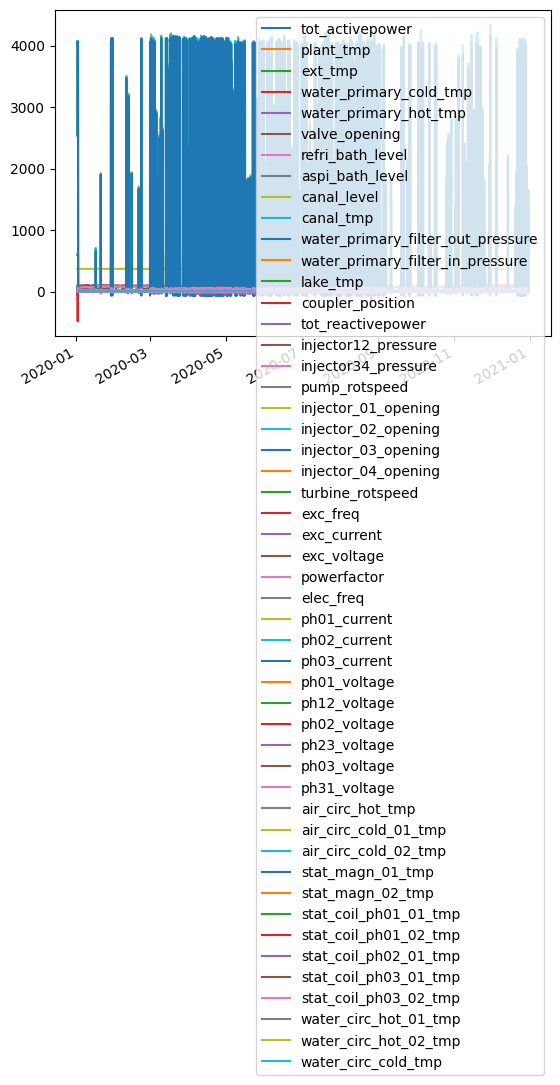

In [8]:
rds_u4.data_dict["train"].measurements[::100].plot()

In [9]:
rds_u4.data_dict["train"].measurements[::100].hvplot.explorer(y=[v for v in temperature_attrs.attribute_name.values])

BokehModel(combine_events=True, render_bundle={'docs_json': {'88c2cbc7-19ff-479c-9f0b-d6df62570c68': {'version…

An other example would be to look at injector pressures:

In [10]:
df = rds_u4.data_dict["train"].info
temperature_attrs = df[df.attribute_name.str.contains("injector")]
temperature_attrs

,Unnamed: 0,signal_name,attribute_name,asset,unit,element,signal_type,control_signal,input_feature,output_feature,core_attribute
15,15,FMHL_SUP_VEY.MHL_VG4_PRMTU_PRES_EAU_PT12,injector12_pressure,Veytaux 1,VG4,MIV1,Measurement,True,False,True,False
16,16,FMHL_SUP_VEY.MHL_VG4_PRMTU_PRES_EAU_PT34,injector34_pressure,Veytaux 1,VG4,MIV2,Measurement,True,False,True,False
18,18,FMHL_SUP_VEY.MHL_VG4_MIPMTU_PT1_OUVERTURE,injector_01_opening,Veytaux 1,VG4,Turbine,Measurement,True,False,True,False
19,19,FMHL_SUP_VEY.MHL_VG4_MIPMTU_PT2_OUVERTURE,injector_02_opening,Veytaux 1,VG4,Turbine,Measurement,True,False,True,False
20,20,FMHL_SUP_VEY.MHL_VG4_MIPMTU_PT3_OUVERTURE,injector_03_opening,Veytaux 1,VG4,Turbine,Measurement,True,False,True,False
21,21,FMHL_SUP_VEY.MHL_VG4_MIPMTU_PT4_OUVERTURE,injector_04_opening,Veytaux 1,VG4,Turbine,Measurement,True,False,True,False
50,50,FEAT.Veytaux_1.VG4.Control.Control_Feature.tim...,timer_injector_opening,Veytaux 1,VG4,Control,Feature,True,False,False,False


In [11]:
rds_u4.data_dict["train"].measurements[::100].hvplot.explorer(y=["injector12_pressure", "injector34_pressure"])

BokehModel(combine_events=True, render_bundle={'docs_json': {'2bd4d3ce-cf88-4b66-ba8e-35b46875eafd': {'version…

As you can see, the test set is quite short compared to the training set. For injector 1, the test distribution is different compared to the training distribution (distribution shift).
Be aware that such distribution shifts can greatly influence the performance of your model.

In [12]:
rds_u4.data_dict["test"].measurements[::100].hvplot.explorer(y=["injector12_pressure", "injector34_pressure"])

BokehModel(combine_events=True, render_bundle={'docs_json': {'690dc1b5-d9b2-4874-a9ec-473a732cce63': {'version…

We can also explore the machines in operation next to each other:

The training data sets.

In [13]:
plt = (
    rds_u4.data_dict["train"].measurements[::1000].hvplot()
    + rds_u5.data_dict["train"].measurements[::1000].hvplot()
    ).cols(1)

plt

:Layout
   .NdOverlay.I  :NdOverlay   [Variable]
      :Curve   [index]   (value)
   .NdOverlay.II :NdOverlay   [Variable]
      :Curve   [index]   (value)

We see that the test datasets are recorded troughout different seasons, which can have an impact on the recorded data.

In [ ]:
plt = (
    rds_u4.data_dict["test"].measurements[::1000].hvplot()
    + rds_u5.data_dict["test"].measurements[::1000].hvplot()
    + rds_u6.data_dict["test"].measurements[::1000].hvplot()
    ).cols(1)

plt

Now it's your turn. Try to explore the data as much as possible before engineering the solution. The main difficulty in real-world problems often isn't the complexity, but understanding the actual problem you are trying to solve, as there is no "guidance" like in the exercises you saw throughout this class. Remember, there are always trade-offs when selecting a model which you should evaluate before investing a lot of time on the implementation.